# Lab 7:  Control Using Feedback 

Your Name:  <span style="background-color:yellow">Cole Stevens</span>

### NOTES ON SAFETY!!

1) There are two components in this lab that may get extremely hot; the solid state relay, and your heater.  Be very careful when handling these elements to avoid burning yourself.  Make sure that these components are not touching anything that could melt or become damaged.
2) You will be working with relatively high voltages and currents.  They are unlikely to hurt you, but play it safe and always turn off outputs on both of your power supplies before touching or rewiring any circuitry.

### Learning Outcomes

* Design, build, adjust, and troubleshoot a circuit with analog feedback
* Use an op-amp comparator
* Use a solid state relay as a switch
* Obtain evidence that your heater turns on when cold, and off when hot

## Using Feedback for Control

**GOAL**: Obtain evidence that (1) your heater turns on when your thermistor is cold, and (2) your heater turns off when your thermistor is hot.  

In laboratory settings, we often want to design controlled environments in which a **process variable** is maintained at some out-of-equilibrium setpoint.  For example, you may run an experiment that requires a water bath to be kept at a "constant" (within a certain range) temperature.  (Temperature would be the process variable in this case.)  A PID controller (Partial-Integral-Differential) is often used to achieve this control; output on a PID controller is nuanced and depends on things like the rate of change of the process variable.  In this lab, you will design and build a very pared down version of a controller that just has two modes:  on and off.

Below is a schematic of the control loop you will construct in this lab.  Think about which pieces you constructed in Lab 6, and which pieces you will need to add in this lab.

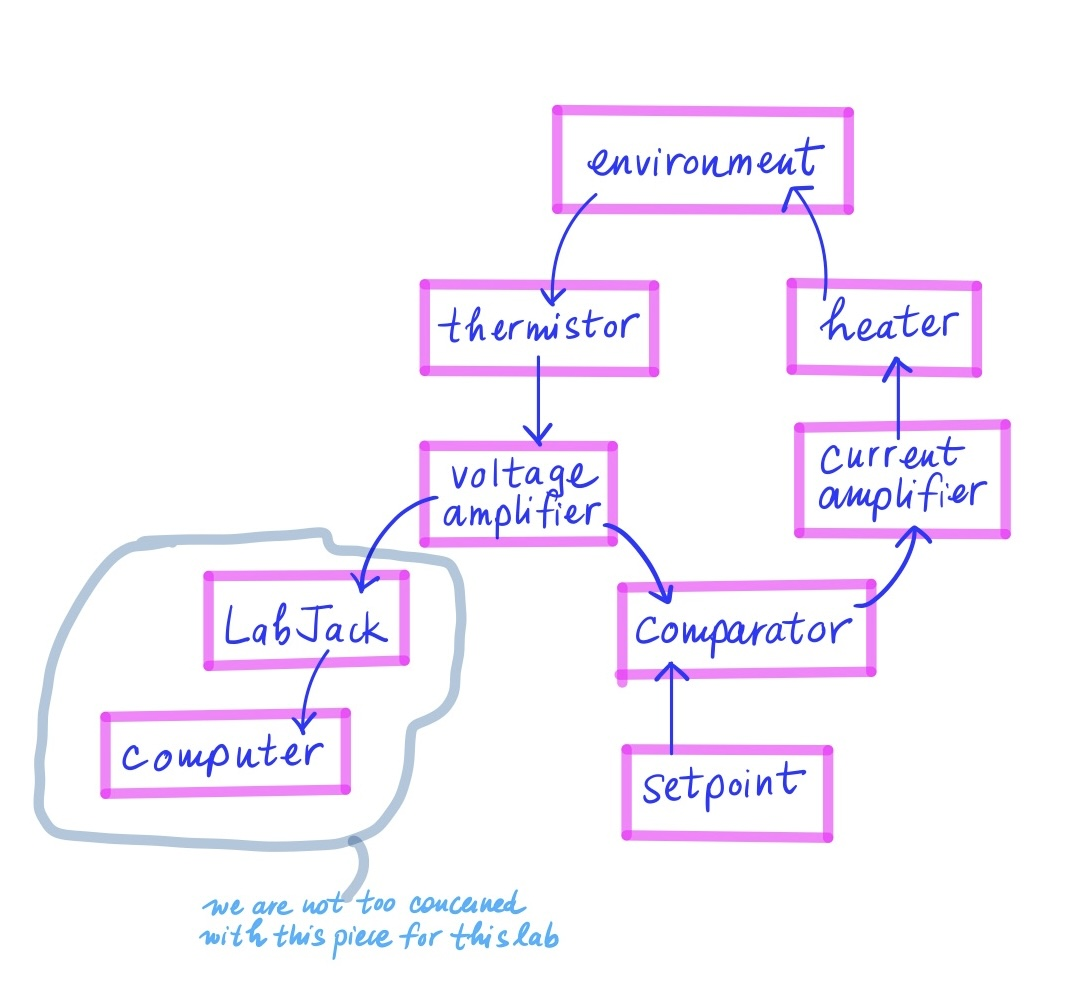

### The LM311 Comparator

So far this quarter, we have been using the LM741 op amp.  This op amp doesn't make a great comparator, because it isn't designed to consistently output voltages that are near its rails.  For example, if you try to use a LM741 as a comparator with the rails set to +15 V and 0 V, you'll get close to 15 V on the high end, but never lower than about 1.9 V on the low end.  This is a problem for this lab, because in order to turn our heater off, we need a comparator that will produce a $V_\text{out}$ very close to 0 V.

The LM311 op amp is, however, designed to be a comparator.  Below is the pinout and circuit diagram for the LM311 that you will use for this lab.  Be careful -- it has some key differences from the LM741 pinout.  Note that the transistor in the circuit diagram below is part of the op amp and not a separate component.  The $1\;k\Omega$ resistor is a "pull up" resistor and **is** a separate component.  Your $V_\text{out}$ will be at 'EMIT OUT.'

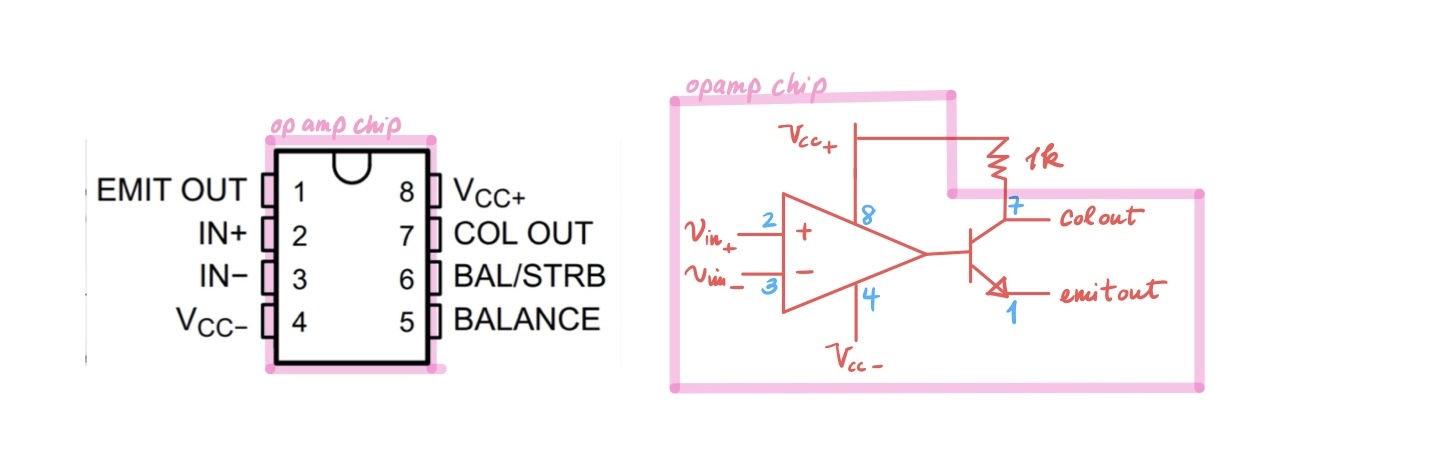

### Setting Your Setpoint

In the control loop feedback diagram above, the setpoint is a voltage input into your comparator which corresponds to a threshold temperature.  **When your thermistor is above the threshold temperature, your comparator should be "off" (outputting 0 A).  When your thermistor is below the threshold temperature, your comparator should be "on" (outputting some nonzero amperage)**.

**Exercise 1A - Determine Your Setpoint Voltage**:  Look back at your voltage data from Exercise 4 in Lab 6.  Choose a voltage that corresponds to a temperature slightly higher than room temperature -- something like what you achieved by placing the thermistor between your fingers.  This will be your setpoint voltage, $V_\text{sp}$.  (Note that $V_\text{sp}$ might be above or below your voltage measured at room temperature depending on the placement of your thermistor in its voltage divider.)

##### <span style="background-color:yellow">Respond to Exercise 1A below.</span>

$V_\text{sp,\;theoretical} = 5.5 V$

=================================================================

Recall from lecture that the $v_\text{out}$ for an LM311 comparator is

$v_\text{out} = A_{0}(v_{-}-v_{+})$

where $v_{+}$ and $v_{-}$ are the inputs to your LM311 comparator.  Even though $A_{0}\approx 10^{5}$, $v_\text{out}$ is limited by the rails $v_\text{cc+}$ and $v_\text{cc-}$ such that

if $v_\text{out}>v_\text{cc+}$, $v_\text{out}\Rightarrow v_\text{cc+}$

and

if $v_\text{out}<v_\text{cc-}$, $v_\text{out}\Rightarrow v_\text{cc-}$.


**Exercise 1B - Determine Your Setpoint Input**:

Take $v_\text{Therm}$ to be the voltage into your comparator that comes from your amplified thermistor circuit, and $v_\text{sp}$ to be your setpoint voltage.

* If in your thermistor voltage divider you chose **$R_{1} = R_\text{Therm}$**, then an increase in temperature produces an increase in $v_\text{in}$, you want your comparator to be "on" for values of $v_\text{in}< v_\text{sp}$ and "off" for values of values of $v_\text{in}> v_\text{sp}$, therefore **$v_{+} = v_\text{in}$** and **$v_{-} = v_\text{sp}$**.
  
* If in your thermistor voltage divider you chose **$R_{2} = R_\text{Therm}$**, then an increase in temeprature produces a decrease in $v_\text{in}$, you want your comparator to be "on" for values of $v_\text{in}> v_\text{sp}$ and "off" for values of values of $v_\text{in}< v_\text{sp}$, therefore **$v_{-} = v_\text{in}$** and **$v_{+} = v_\text{sp}$**. 


<span style="background-color:yellow">For my comparator,</span>

$v_{+} = v_\text{input}$

and

$v_{-} = v_\text{sp}$

**You will test your comparator (in isolation) to make sure it is behaving as expected before integrating it with the rest of your circuit.**

### Conference:  Design Your Circuit

In this lab, you will build upon your thermistor circuit from Lab 6.  Please redraw your thermistor circuit, and add the components listed below in such a way that your heater will have approximately 25 Watts running through it when your thermistor is below a temperature setpoint, and approximately 0 Watts running through it when your thermistor is above a that temperature setpoint.  

Components to utilize:

* Your thermistor circuit from Lab 6
* An LM311 op-amp comparator with rails at 0 V and 5 V, and inputs as determined in Exercise 1
* A solid state relay to switch your heater on and off (instructor will describe specifics)  
* A heater that can run at roughly 10 V max, 2.5 A ($\approx\; 1\;\Omega$)
* An ammeter at the base of your Darlington Pair
* A high voltage, high current power supply
* Various resistors, cables, etc.

**EXERCISE 2**:  Spend 15-20 minutes designing your circuit with your neighbors.  Be specific in your design; think through your power sources, calculate specific resistor values needed, etc.

We will discuss as a class and converge on a design.

<span style="background-color:yellow">Below, include your circuit diagram agreed upon by the class.</span>

### Test Your Comparator

As we've seen previously, it's always a good idea to test components before you add them to a larger circuit, when possible.  To that end, build your comparator and test it before connecting it to your thermistor circuit.  Your benchtop power supply has two outputs; use one output as your 0 V and 5 V rails, and the other output as a variable $V_\text{in}$ for your comparator that simulates the voltage coming in from your thermistor circuit.  At the (emit) output of your comparator, add a $1\;k\Omega$ resistor that goes to ground.  

**EXERCISE 3**:  Measure the voltage across the resistor, $V_\text{out}$, and the current through the resistor, $I_\text{out}$, for various values of $V_\text{in}$ (see circuit diagram below).  Report your values below.  Make sure your comparator behaves as expected relative to your setpoint.  

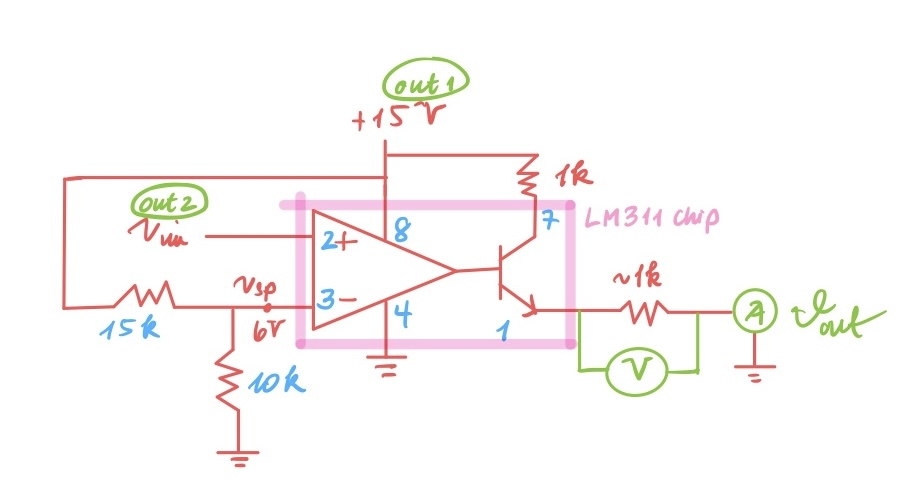

<span style="background-color:yellow">Respond to Exercise 3 below.<br>
0 - 3.8 V, I = 0 mA <br>
3.9 V, I = 0.042 mA <br>
4 - 8 V, I = 0.12 mA <br>
<br>
The measured voltage output from the comparator changed depending on the resistance put in series with the outputting circuit of the comparator. The voltage jump from about 0 V to an non-zero value happens when the voltage input is 3.9 V. The phenomenae was measured, recorded, and plotted below.
</span>

For V_input of 6V
|R_out (Ohm)|V_drop (V)|
|-|-|
|100|0.0126|
|3000|0.3785|
|10k|1.254|
|30k|3.67|
|100k|4.38|
|300k|4.55|
|900k|4.61|
|2M|4.63|
|10M|4.64|

In [1]:
import matplotlib.pyplot as plt
import numpy as np

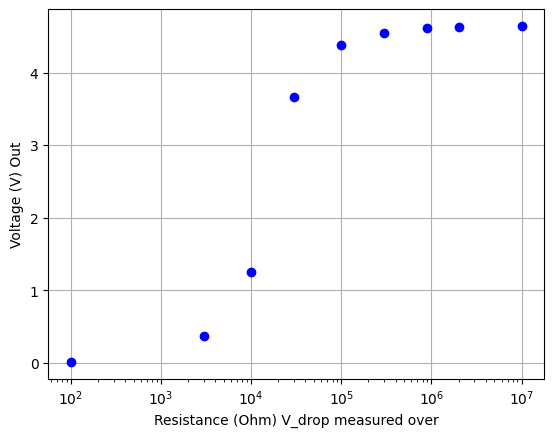

In [5]:
R = [100, 3000, 10000, 30000, 100000, 300000, 900000, 2000000, 10000000]
V = [0.0126, 0.3785, 1.254, 3.67, 4.38, 4.55, 4.61, 4.63, 4.64]
plt.semilogx(R, V, 'bo')
plt.grid(True)
plt.xlabel('Resistance (Ohm) V_drop measured over')
plt.ylabel('Voltage (V) Out')
plt.savefig('Comparator_V_out_weirdness_4Mar2026.png')

<span style="background-color:yellow">
This was repeated after shifting the comparator to a different part of the breadboard.
</span>

<span style="background-color:yellow">
Changing R_6 (see circuit diagram) in the voltage divider, thereby changing the set point voltage, did not change it in the resultant voltage out. However changing R_5 (see circuit diagram) DOES change it so the voltage output does correspond with the changed set voltage. That is, until the set point voltage is above 3.9 V, then the voltage output jump will ONLY happen at 3.9 V, even if the set point voltage is 7 V. <br>
After changing the V_cc+ input, it seems that the "actual" set point voltage is V_cc+ - 1.1 V. For example, changing the V_cc+ to 8 V let me have a max set point voltage of 6.9 V. <br>
<br>
Restoring R_5 and R_6 to 1k and 1.6k Ohms respectively, and changing the V_cc+ to 6.6V, created a output voltage jump from 0.14 V to 6.1 V when the input voltage reaches 5.4 V, very close to the desired 5.5 set point voltage. However, the problem of the output voltage changing depending on resistor to measure the voltage drop over is still present. 
</span>

### Add Your Solid State Relay, Heater, and High Voltage Power Supply

Add your Solid State Relay (SSR), Heater, and High Voltage Power Supply to follow your comparator.  **Start with your high voltage power supply set to 6V or so to monitor its behavior.**.  See the schematic for the SSR below.  Note that you do not need to connect the ground on the output/load side of the relay to the ground on the switch side.  Also be sure you have a resistor between your comparator and SSR ($10-100\Omega$ should do the trick) to limit the current input to the SSR.

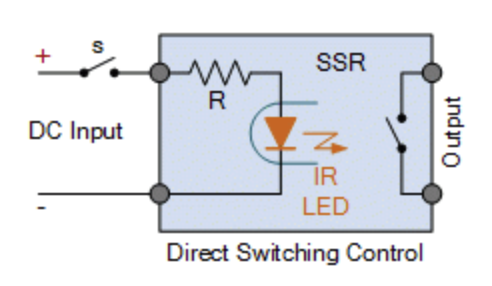

**EXERCISE 4**:  Test your comparator again, but this time measure (1) $I_\text{in}$, the current into your SSR, (2) $I_\text{out}$, the current output by the heater power supply, (3) $V_\text{out}$, the voltage output by the heater power supply, and (4) $W_\text{out}$, the power output by the heater power supply.  Report your measurements in a table and add any comments below.  

**Remember:  your SSR and heater may get very hot!! Be careful!**

<span style="background-color:yellow">Respond to Exercise 4 below.</span>

### Connect Your Heater Circuit to Your Thermistor Circuit!

Now replace your $V_\text{in}$ with the output from your thermistor's amplifier.  You may need to rearrange your rails -- take care to do this correctly.  Include a completed circuit diagram and wiring/breadboard diagram.

**EXERCISE 5**:  Does your heater turn on when your thermistor is "cold," and off when it is "hot"?  Show evidence that it does.

<span style="background-color:yellow">Respond to Exercise 5 below.</span>